In [47]:
from datetime import date
from pathlib import Path

save_dir = 'Output' # Output folder in current directory
assert(Path(save_dir)).exists()

figures_data_dir = 'Data' # FIXME (keep the trailing "/"!)
assert(Path(figures_data_dir)).exists()

## Libraries

In [48]:
import matplotlib
from matplotlib import rcParams
from matplotlib import ticker as mtick
mpl = matplotlib

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['figure.figsize'] = (6.0,4.0) # default = (6.0, 4.0)
mpl.rcParams['font.size']      = 12       # default = 10

mpl.rcParams['axes.linewidth']    = 0.75 # default = 1.0
mpl.rcParams['lines.linewidth']   = 1.5 # default = 1.0
mpl.rcParams['patch.linewidth']   = 1.0 # default = 1.0
mpl.rcParams['grid.linewidth']    = 0.5 # default = 0.5
mpl.rcParams['xtick.major.width'] = 1.0 # default = 0.5
mpl.rcParams['xtick.minor.width'] = 0.0 # default = 0.5
mpl.rcParams['ytick.major.width'] = 1.0 # default = 0.5
mpl.rcParams['ytick.minor.width'] = 0.0 # default = 0.5

def make_nice_axis(ax):
    """ Function to beautify axis"""
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_tick_params(pad=10,top='on',direction='in')
    ax.yaxis.set_tick_params(pad=10,top='on',direction='in')
    ax.xaxis.set_tick_params(labelsize=10)
    ax.yaxis.set_tick_params(labelsize=10)

import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='Arial')
import pandas as pd
import os
def save_figure(fig, fig_file):
    """
    Save the given figure object as PDF and PNG formats.

    Parameters:
    fig (matplotlib.figure.Figure): The figure object to be saved.
    fig_file (str): The file path (including the file name without extension) where the figure will be saved.

    Returns:
    None
    """
    os.makedirs(os.path.dirname(fig_file), exist_ok=True)
    fig.savefig(fname=fig_file + ".pdf", dpi=300, format='pdf',bbox_inches='tight')
    fig.savefig(fname=fig_file + ".png", dpi=1200, format='png',bbox_inches='tight')

### SI 1 Dimer ###

In [49]:
path_to_fig1_data = figures_data_dir + '/SI1/data/'
figSI1_data_dimer = pd.read_csv(path_to_fig1_data + 'dimer_benchmark_results.csv')

Output/figSI1/dimer_combined


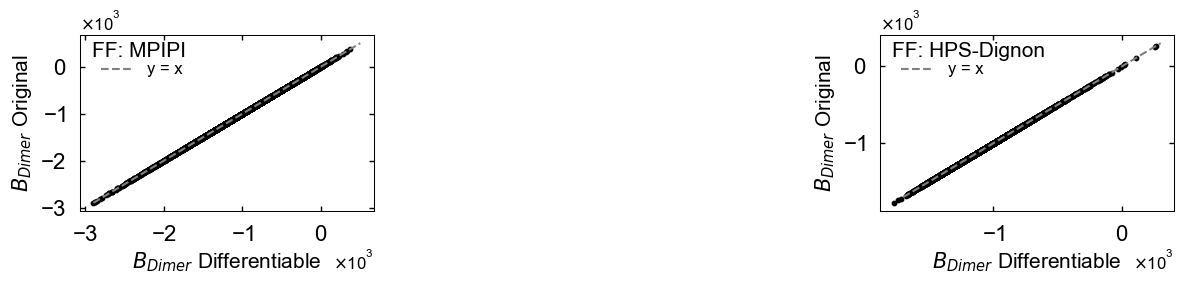

In [50]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))
make_nice_axis(ax1)
make_nice_axis(ax2)
make_nice_axis(ax3)

# ========== LEFT PLOT: MPIPI-GG ==========
diff_values_mpipi = figSI1_data_dimer['mpipi']
orig_values_mpipi = figSI1_data_dimer['mpipi_orig']


# For left y + x axis
ax1.tick_params(axis='both', labelsize=16)
ax1.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax1.xaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

ax1.set_xticks([-3000, -2000, -1000, 0])
ax1.set_yticks([-3000, -2000, -1000, 0])
ax1.scatter(diff_values_mpipi, orig_values_mpipi, color='k', s = 10)
ax1.plot(np.linspace(-2900, 500, 100), np.linspace(-2900, 500, 100), color = 'grey', linewidth = 1.5, linestyle = '--', label = 'y = x')
ax1.legend( frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.93))
ax1.text(0.04, 0.96, "FF: MPIPI", transform=ax1.transAxes, verticalalignment='top',fontsize=15)

ax1.set_xlabel('$B_{Dimer}$ Differentiable',fontsize=15)
ax1.set_ylabel('$B_{Dimer}$ Original',fontsize=15)

# ========== MIDDLE PLOT: EMPTY (for future use) ==========
ax2.axis('off')  # Hide the middle subplot

# ========== RIGHT PLOT: HPS-Dignon ==========
diff_values_hps = figSI1_data_dimer['hps_dignon']
orig_values_hps = figSI1_data_dimer['hps_dignon_orig']

ax3.tick_params(axis='both', labelsize=16)
ax3.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax3.xaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax3.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

ax2.set_xticks([-1500, -1000, -500, 0])
ax2.set_yticks([-1500, -1000, -500, 0])
ax3.scatter(diff_values_hps, orig_values_hps, color = 'k', s = 10)
ax3.plot(np.linspace(-1700, 300, 100), np.linspace(-1700, 300, 100), color = 'grey', linewidth = 1.5, linestyle = '--', label = 'y = x')
ax3.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.93))
ax3.text(0.04, 0.96, "FF: HPS-Dignon", transform=ax3.transAxes, verticalalignment='top',fontsize=15)

ax3.set_xlabel('$B_{Dimer}$ Differentiable',fontsize=15)
ax3.set_ylabel('$B_{Dimer}$ Original',fontsize=15)
plt.tight_layout()

fig_save = True
fig_name = 'figSI1/dimer_combined'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()

### SI 1 RPA ###

In [51]:
figSI1_data_rpa = pd.read_csv(path_to_fig1_data + 'rpa_benchmark_results.csv')

Output/figSI1/RPA_combined


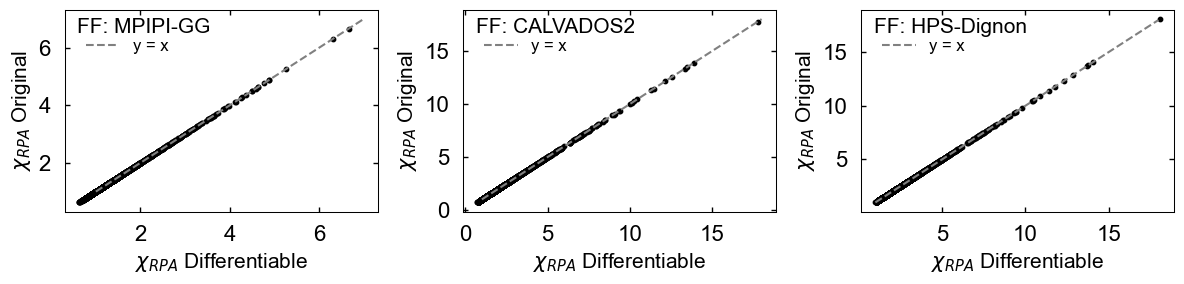

In [52]:

# Create figure with three subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))
make_nice_axis(ax1)
make_nice_axis(ax2)
make_nice_axis(ax3)
# ========== LEFT PLOT: MPIPI-GG ==========
diff_values_mpipi = figSI1_data_rpa['mpipi']
orig_values_mpipi = figSI1_data_rpa['mpipi_orig']
ax1.tick_params(axis='both', labelsize=16)
ax1.set_xticks([2, 4, 6])
ax1.set_yticks([2, 4, 6])

ax1.scatter(diff_values_mpipi, orig_values_mpipi, color = 'k', s = 10)
ax1.plot(np.linspace(1, 7, 100), np.linspace(1, 7, 100), color = 'grey', linewidth = 1.5, linestyle = '--', label = 'y = x')
ax1.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.93))
ax1.text(0.04, 0.96, "FF: MPIPI-GG", transform=ax1.transAxes, verticalalignment='top',fontsize=15)

ax1.set_xlabel('$\chi_{RPA}$ Differentiable',fontsize=15)
ax1.set_ylabel('$\chi_{RPA}$ Original',fontsize=15)

# ========== MIDDLE PLOT: CALVADOS2 ==========
diff_values_calvados = figSI1_data_rpa['calvados2']
orig_values_calvados = figSI1_data_rpa['calvados2_orig']
ax2.tick_params(axis='both', labelsize=16)
ax2.set_xticks([0, 5, 10, 15])
ax2.set_yticks([0, 5, 10, 15])

ax2.scatter(diff_values_calvados, orig_values_calvados, color = 'k', s = 10)
ax2.plot(np.linspace(1, 18, 100), np.linspace(1, 18, 100), color = 'grey', linewidth = 1.5, linestyle = '--', label = 'y = x')
ax2.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.93))
ax2.text(0.04, 0.96, "FF: CALVADOS2", transform=ax2.transAxes, verticalalignment='top',fontsize=15)

ax2.set_xlabel('$\chi_{RPA}$ Differentiable',fontsize=15)
ax2.set_ylabel('$\chi_{RPA}$ Original',fontsize=15)

# ========== RIGHT PLOT: HPS-Dignon ==========
diff_values_hps = figSI1_data_rpa['dignon']
orig_values_hps = figSI1_data_rpa['dignon_orig']
ax3.tick_params(axis='both', labelsize=16)
ax3.set_xticks([5, 10, 15])
ax3.set_yticks([5, 10, 15])

ax3.scatter(diff_values_hps, orig_values_hps, color = 'k', s = 10)
ax3.plot(np.linspace(1, 18, 100), np.linspace(1, 18, 100), color = 'grey', linewidth = 1.5, linestyle = '--', label = 'y = x')
ax3.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.93))
ax3.text(0.04, 0.96, "FF: HPS-Dignon", transform=ax3.transAxes, verticalalignment='top',fontsize=15)

ax3.set_xlabel('$\chi_{RPA}$ Differentiable',fontsize=15)
ax3.set_ylabel('$\chi_{RPA}$ Original',fontsize=15)

plt.tight_layout()
fig_save = True
fig_name = 'figSI1/RPA_combined'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()

### SI 1 FINCHES ###

In [53]:
figSI1_data_finches = pd.read_csv(path_to_fig1_data + 'finches_benchmark_results.csv')

Output/figSI1/finches_combined


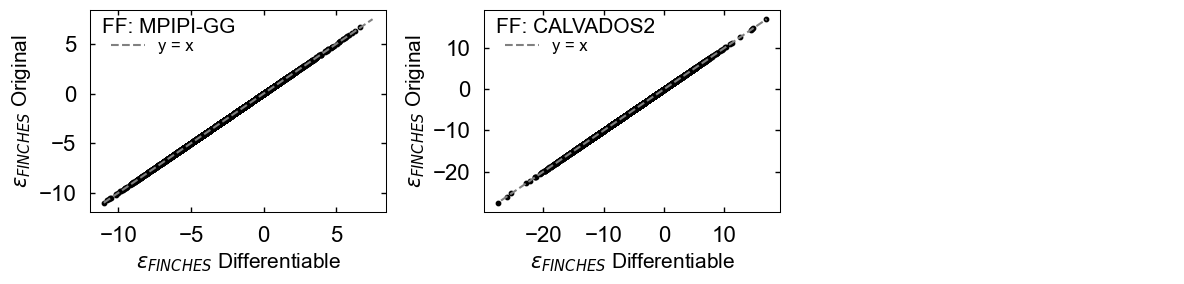

In [54]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3))
make_nice_axis(ax1)
make_nice_axis(ax2)
make_nice_axis(ax3)
# ========== LEFT PLOT: MPIPI-GG ==========
diff_values_mpipi = figSI1_data_finches['FINCHES_mpipi_new']
orig_values_mpipi = figSI1_data_finches['FINCHES_calvados_ref'] # original values are flipped in the csv file
ax1.tick_params(axis='both', labelsize=16)
ax1.set_xticks([-10, -5, 0, 5])
ax1.set_yticks([-10, -5, 0, 5])

ax1.scatter(diff_values_mpipi, orig_values_mpipi, color = 'k', s = 10)
ax1.plot(np.linspace(-11, 7.5, 100), np.linspace(-11, 7.5, 100), color = 'grey', linewidth = 1.5, linestyle = '--', label = 'y = x')
ax1.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.93))
ax1.text(0.04, 0.96, "FF: MPIPI-GG", transform=ax1.transAxes, verticalalignment='top',fontsize=15)

ax1.set_xlabel('$\epsilon_{FINCHES}$ Differentiable',fontsize=15)
ax1.set_ylabel('$\epsilon_{FINCHES}$ Original',fontsize=15)

# ========== MIDDLE PLOT: CALVADOS2 ==========
diff_values_calvados = figSI1_data_finches['FINCHES_calvados_new']
orig_values_calvados = figSI1_data_finches['FINCHES_mpipi_ref'] # original values are flipped in the csv file
ax2.tick_params(axis='both', labelsize=16)
ax2.set_xticks([-20, -10, 0, 10])
ax2.set_yticks([-20, -10, 0, 10])


ax2.scatter(diff_values_calvados, orig_values_calvados, color = 'k', s = 10)
ax2.plot(np.linspace(-27, 17, 100), np.linspace(-27, 17, 100), color = 'grey', linewidth = 1.5, linestyle = '--', label = 'y = x')
ax2.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.93))
ax2.text(0.04, 0.96, "FF: CALVADOS2", transform=ax2.transAxes, verticalalignment='top',fontsize=15)

ax2.set_xlabel('$\epsilon_{FINCHES}$ Differentiable',fontsize=15)
ax2.set_ylabel('$\epsilon_{FINCHES}$ Original',fontsize=15)

# ========== RIGHT PLOT: EMPTY (for future use) ==========
ax3.axis('off')  # Hide the third subplot


plt.tight_layout()
fig_save = True
fig_name = 'figSI1/finches_combined'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()

### SI 2 ###

In [55]:
path_to_data = figures_data_dir + '/SI2/data/'

Output/figSI2/time_many_value_batch


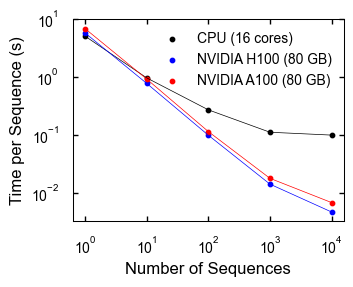

Output/figSI2/time_many_seq_lengths


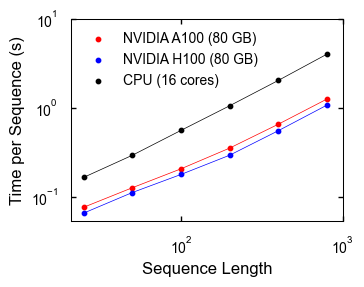

In [56]:
import ast

base_size = 3.5

df_sv = pd.read_csv(path_to_data + 'single_value_batch_summary.csv')
df_mv = pd.read_csv(path_to_data + 'many_value_batch_summary.csv')
df_sl = pd.read_csv(path_to_data + 'many_seq_lengths_batch.csv')

COLOR_MAP = {'a100': 'red', 'h100': 'blue'}

def get_color_and_label(label, cpu_seen):
    if 'quest' in label:
        return 'black', ('CPU' if not cpu_seen else '_nolegend_'), True
    return COLOR_MAP.get(label, 'gray'), label.upper(), cpu_seen

fig, ax = plt.subplots(1, 1, figsize=(base_size, base_size*0.75))
make_nice_axis(ax)
cpu_seen = False
for label in df_mv['label'].unique():
    df_mv_label = df_mv[df_mv['label'] == label]
    label_name = df_mv_label['label'].values[0]
    if label_name == 'quest10' or label_name == 'quest11' or label_name == 'quest12':
        continue
    times = ast.literal_eval(df_mv_label['time'].values[0])
    seqs = ast.literal_eval(df_mv_label['seqs'].values[0])
    color, legend_label, cpu_seen = get_color_and_label(label, cpu_seen)
    legend_label = 'NVIDIA ' + legend_label + ' (80 GB)' if 'CPU' not in legend_label else legend_label + ' (16 cores)'
    ax.scatter(seqs, times, label=legend_label, color=color, s = 10)
    ax.plot(seqs, times, color=color, linewidth = 0.5)
ax.semilogx()
ax.semilogy()
ax.set_xlabel('Number of Sequences')
ax.set_ylabel('Time per Sequence (s)')
ax.set_yticks([0.01, 0.1, 1, 10])
ax.legend(loc = 'upper right', frameon=False, fontsize = 10)
print(save_dir + '/figSI2/time_many_value_batch')
save_figure(fig, fig_file = save_dir + '/figSI2/time_many_value_batch')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(base_size, base_size*0.75))
make_nice_axis(ax)
cpu_seen = False
for label in df_sl['label'].unique():
    df_sl_label = df_sl[df_sl['label'] == label]
    label_name = df_sl_label['label'].values[0]
    if label_name == 'quest10' or label_name == 'quest11' or label_name == 'quest12':
        continue
    times = ast.literal_eval(df_sl_label['time'].values[0])
    seqs = ast.literal_eval(df_sl_label['seqs'].values[0])
    color, legend_label, cpu_seen = get_color_and_label(label, cpu_seen)
    legend_label = 'NVIDIA ' + legend_label + ' (80 GB)' if 'CPU' not in legend_label else legend_label + ' (16 cores)'
    ax.scatter(seqs, np.array(times)/ 100, label=legend_label, color=color, s = 10)
    ax.plot(seqs, np.array(times)/ 100, color=color, linewidth = 0.5)
ax.semilogx()
ax.semilogy()
ax.set_xlabel('Sequence Length')
ax.set_ylabel('Time per Sequence (s)')
ax.set_xticks([100, 1000])
ax.set_yticks([0.1, 1,10])
ax.legend(loc = 'upper left', frameon=False, fontsize = 10)
print(save_dir + '/figSI2/time_many_seq_lengths')
save_figure(fig, fig_file = save_dir + '/figSI2/time_many_seq_lengths')
plt.show()




### SI 3 ###

In [57]:
path_to_fig3_data = figures_data_dir + '/SI3/data/'
figSI3_data_RPA = path_to_fig3_data + 'RPA_mpipi.txt'

Output/figSI3/RPA_mpipi


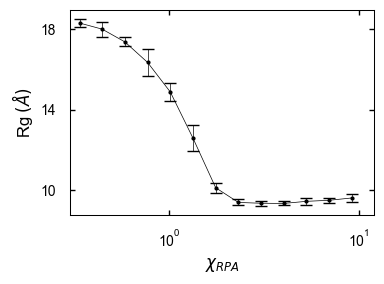

In [58]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
make_nice_axis(ax)

log_spaced_vals = np.logspace(np.log10(0.337), np.log10(83.01), 21)
RPA_Rgs = []

with open(figSI3_data_RPA, 'r') as file:
    data = file.read()

data_lines = data.split('\n')
i = 0

rg_dict = {
    '0': [],
    '5': [],
    '10': [],
    '15': [],
    '20': [],
    '25': [],
    '30': [],
    '35': [],
    '40': [],
    '45': [],
    '50': [],
    '55': [],
    '60': [],
    '65': [],
    '70': [],
    '75': [],
    '80': [],
    '85': [],
    '90': [],
    '95': [],
    '100': [],
}

while i < len(data_lines):
    if 'data' in data_lines[i]:
        breaks = data_lines[i].split('_')
        spacing = int(breaks[-1])
        trial_no = int(breaks[-2])
        spacing -= trial_no
        spacing = str(spacing)

        rg_val = data_lines[i+1].split(' ')[-2][:-1]
        rg_dict[spacing].append(float(rg_val))
        i += 1
    else:
        i += 1

rg_vals = np.array(list(rg_dict.values()))
rg_std = np.std(rg_vals, axis = 1)
rg_vals = np.mean(rg_vals, axis = 1)

line_color = "k"
mask = np.array(log_spaced_vals) <= 10
log_spaced_vals = np.array(log_spaced_vals)[mask]
rg_vals = np.array(rg_vals)[mask]
rg_std = np.array(rg_std)[mask]

ax.errorbar(log_spaced_vals, rg_vals, yerr=rg_std, fmt='o-', capsize=4, lw=0.5, color='k',ecolor='k',  markersize=2)
ax.semilogx()
ax.set_xticks([1, 10])
ax.set_yticks([10, 14, 18])
ax.set_xlim(0.3, 12)
ax.set_ylabel('Rg $(\AA)$')
ax.set_xlabel('$\chi_{RPA}$')
plt.tight_layout()

fig_save = True
fig_name = 'figSI3/RPA_mpipi'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()

### SI 4 ### 

In [59]:
path_to_fig4_data = figures_data_dir + '/SI4/data/'
fig4a_data_left = pd.read_csv(path_to_fig4_data + 'chi_epsilon_summary_calvados.csv')
fig4b_data_right = pd.read_csv(path_to_fig4_data + 'epsilon_chi_summary_calvados.csv')

Output/figSI4/chi_meanepsilon


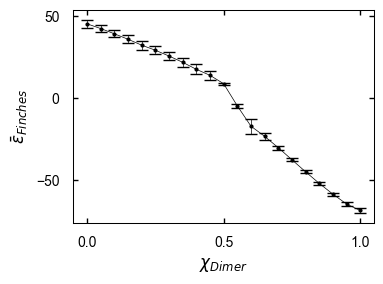

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax)

ax.errorbar(fig4a_data_left['chi'], fig4a_data_left['mean_epsilon'], yerr=fig4a_data_left['std_epsilon'], fmt='o-', capsize=4, 
             lw=0.5, color='k', ecolor='k', markersize=2)
ax.set_xlabel(r'$\chi_{Dimer}$')
ax.set_ylabel(r'$\bar{\epsilon}_{Finches}$')
plt.tight_layout()
ax.set_yticks([-50, 0, 50])
ax.set_xticks([0, 0.5, 1])
fig_save = True
fig_name = 'figSI4/chi_meanepsilon'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()

Output/figSI4/epsilon_meanchi


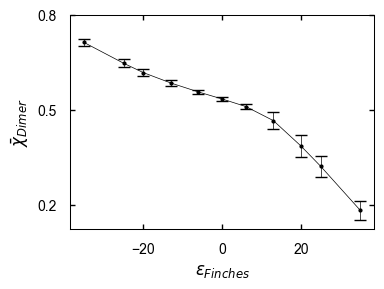

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax)
ax.errorbar(fig4b_data_right['epsilon'], fig4b_data_right['mean_chi'], yerr=fig4b_data_right['std_chi'], fmt='o-', capsize=4, 
             lw=0.5, color='k', ecolor='k', markersize=2)
ax.set_xlabel(r'$\epsilon_{Finches}$')
ax.set_ylabel(r'$\bar{\chi}_{Dimer}$')
plt.tight_layout()
ax.set_yticks([0.2, 0.5, 0.8])
fig_save = True
fig_name = 'figSI4/epsilon_meanchi'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()

### SI 5 ###

In [62]:
path_to_si5_data = figures_data_dir + '/SI5/data/'
embedding = np.load(path_to_si5_data + 'matched_dimer_frequencies.npy')
labels_ESM2 = np.load(path_to_si5_data + 'matched_ESM2_labels.npy')
labels_dimer = np.load(path_to_si5_data + 'matched_dimer_labels.npy')

n_IDRome = 8521
n_dimer = 8521
n_finches = 8521


y_true = np.concatenate([
    np.full(n_IDRome, 0),
    np.full(n_dimer, 1),
    np.full(n_finches, 2),
    ])

Output/figSI5/joint_UMAP


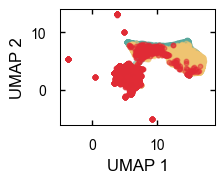

Output/figSI5/matched_IDRome


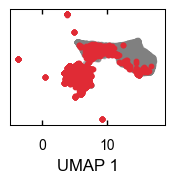

Output/figSI5/matched_dimer_designed


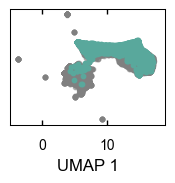

Output/figSI5/matched_finches_designed


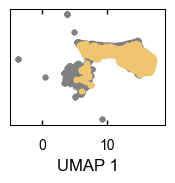

In [63]:
# First - joint embedding + defining some things like colors, sub-embeddings, etc.
from matplotlib.patches import Patch

base_size = 2

embedding_IDRome = embedding[:n_IDRome]
embedding_dimer = embedding[n_IDRome:n_IDRome + n_dimer]
embedding_finches = embedding[n_IDRome + n_dimer:]

colors = ['#e02b35', '#59a89c', '#f0c571'] # Red, Blue, Yellow
labels = ['IDRome', 'Dimer', 'Finches']

color_labels = np.concatenate([
    np.zeros(n_IDRome),
    1 * np.ones(n_dimer),
    2 * np.ones(n_finches),
])

### JOINT EMBEDDING PLOTTING - NOT USED RN ###
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))

# plot combined embedding first
make_nice_axis(ax)

for i, (color, label) in enumerate(zip(colors, labels)):
    mask = color_labels == i
    ax.scatter(embedding[mask, 0], embedding[mask, 1], 
               c = color, label = label, alpha = 0.5, s = 10)

ax.scatter(embedding_IDRome[:, 0], embedding_IDRome[:, 1], c = colors[0], alpha = 0.5, s = 10)

legend_elements = [Patch(facecolor = color, label = label, alpha = 1.0) for color, label in zip(colors, labels)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([0, 10])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])



fig_save = True
fig_name = 'figSI5/joint_UMAP'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)
    
plt.show()
### END OF JOINT EMBEDDING PLOTTING

# subpanel - plot the bioIDRs in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_finches[: ,0], embedding_finches[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_dimer[: ,0], embedding_dimer[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_IDRome[:, 0], embedding_IDRome[:, 1], 
           c = colors[0], label = 'bioIDRs', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])

fig_save = True
fig_name = 'figSI5/matched_IDRome'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)
    
plt.show()

# subpanel - plot the dimer-designed sequences in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_finches[: ,0], embedding_finches[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_IDRome[: ,0], embedding_IDRome[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_dimer[:, 0], embedding_dimer[:, 1], 
           c = colors[1], label = 'dimers', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])

fig_save = True
fig_name = 'figSI5/matched_dimer_designed'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

# subpanel - plot the FINCHES-designed sequences in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_dimer[: ,0], embedding_dimer[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_IDRome[: ,0], embedding_IDRome[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_finches[:, 0], embedding_finches[:, 1], 
           c = colors[2], label = 'finches', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])

fig_save = True
fig_name = 'figSI5/matched_finches_designed'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()


Output/figSI5/cluster_composition_ESM2


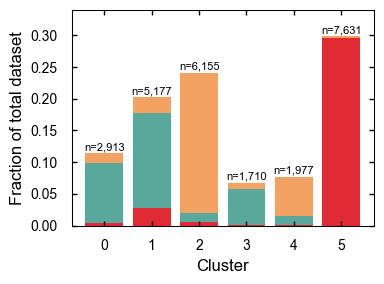

In [64]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, labels_ESM2)
n_total = cm.sum()
n_clusters = cm.shape[1]
cluster_sizes = cm.sum(axis=0)
cluster_labels = [str(i) for i in range(n_clusters)]
true_names = ['Bio', 'Dimer', 'FINCHES']
colors = ['#e02b35', '#59a89c', '#f4a261']
cm_frac = cm.astype(float) / n_total

fig, ax = plt.subplots(figsize=(4, 3))

make_nice_axis(ax)

bottom = np.zeros(n_clusters)
for i, (name, color) in enumerate(zip(true_names, colors)):
    ax.bar(cluster_labels, cm_frac[i], bottom=bottom, label=name, color=color)
    bottom += cm_frac[i]

for j in range(n_clusters):
    ax.text(
        j, bottom[j] + 0.002,
        f'n={cluster_sizes[j]:,}',
        ha='center', va='bottom',
        fontsize=8,
    )
ax.set_ylabel('Fraction of total dataset')
ax.set_xlabel('Cluster')
ax.set_ylim(0, 0.34)

plt.tight_layout()
fig_save = True
fig_name = 'figSI5/cluster_composition_ESM2'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)


plt.show()

Output/figSI5/cluster_composition_dimer


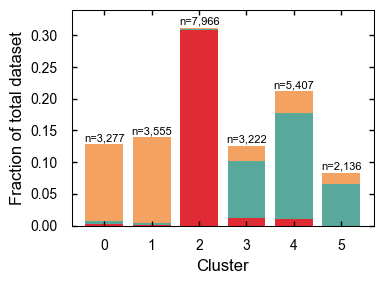

In [65]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, labels_dimer)
n_total = cm.sum()
n_clusters = cm.shape[1]
cluster_sizes = cm.sum(axis=0)
cluster_labels = [str(i) for i in range(n_clusters)]
true_names = ['Bio', 'Dimer', 'FINCHES']
colors = ['#e02b35', '#59a89c', '#f4a261']
cm_frac = cm.astype(float) / n_total

fig, ax = plt.subplots(figsize=(4,3))

make_nice_axis(ax)

bottom = np.zeros(n_clusters)
for i, (name, color) in enumerate(zip(true_names, colors)):
    ax.bar(cluster_labels, cm_frac[i], bottom=bottom, label=name, color=color)
    bottom += cm_frac[i]

for j in range(n_clusters):
    ax.text(
        j, bottom[j] + 0.002,
        f'n={cluster_sizes[j]:,}',
        ha='center', va='bottom',
        fontsize=8,
    )
ax.set_ylabel('Fraction of total dataset')
ax.set_xlabel('Cluster')
ax.set_ylim(0, 0.34)

plt.tight_layout()
fig_save = True
fig_name = 'figSI5/cluster_composition_dimer'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

### SI6 ###

In [66]:
path_to_si6_data = figures_data_dir + '/SI6/data/'
embedding = np.load(path_to_si6_data + 'range_dimer_frequencies.npy')
labels_ESM2 = np.load(path_to_si6_data + 'range_ESM2_labels.npy')
labels_dimer = np.load(path_to_si6_data + 'range_dimer_labels.npy')

n_IDRome = 8521
n_dimer = 21000
n_finches = 11000

y_true = np.concatenate([
    np.full(n_IDRome, 0),
    np.full(n_dimer, 1),
    np.full(n_finches, 2),
    ])

Output/figSI6/joint_UMAP


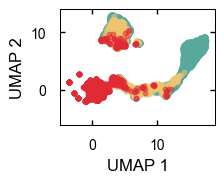

Output/figSI6/range_IDRome


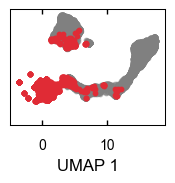

Output/figSI6/range_dimer_designed


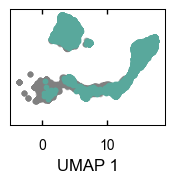

Output/figSI6/range_finches_designed


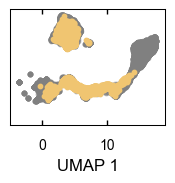

In [67]:
# First - joint embedding + defining some things like colors, sub-embeddings, etc.
from matplotlib.patches import Patch

base_size = 2

embedding_IDRome = embedding[:n_IDRome]
embedding_dimer = embedding[n_IDRome:n_IDRome + n_dimer]
embedding_finches = embedding[n_IDRome + n_dimer:]

colors = ['#e02b35', '#59a89c', '#f0c571'] # Red, Blue, Yellow
labels = ['IDRome', 'Dimer', 'Finches']

color_labels = np.concatenate([
    np.zeros(n_IDRome),
    1 * np.ones(n_dimer),
    2 * np.ones(n_finches),
])

### JOINT EMBEDDING PLOTTING - NOT USED RN ###
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))

# plot combined embedding first
make_nice_axis(ax)

for i, (color, label) in enumerate(zip(colors, labels)):
    mask = color_labels == i
    ax.scatter(embedding[mask, 0], embedding[mask, 1], 
               c = color, label = label, alpha = 0.5, s = 10)

ax.scatter(embedding_IDRome[:, 0], embedding_IDRome[:, 1], c = colors[0], alpha = 0.5, s = 10)

legend_elements = [Patch(facecolor = color, label = label, alpha = 1.0) for color, label in zip(colors, labels)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([0, 10])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])



fig_save = True
fig_name = 'figSI6/joint_UMAP'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)
    
plt.show()
### END OF JOINT EMBEDDING PLOTTING

# subpanel - plot the bioIDRs in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_finches[: ,0], embedding_finches[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_dimer[: ,0], embedding_dimer[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_IDRome[:, 0], embedding_IDRome[:, 1], 
           c = colors[0], label = 'bioIDRs', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])

fig_save = True
fig_name = 'figSI6/range_IDRome'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)
    
plt.show()

# subpanel - plot the dimer-designed sequences in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_finches[: ,0], embedding_finches[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_IDRome[: ,0], embedding_IDRome[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_dimer[:, 0], embedding_dimer[:, 1], 
           c = colors[1], label = 'dimers', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])

fig_save = True
fig_name = 'figSI6/range_dimer_designed'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

# subpanel - plot the FINCHES-designed sequences in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_dimer[: ,0], embedding_dimer[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_IDRome[: ,0], embedding_IDRome[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_finches[:, 0], embedding_finches[:, 1], 
           c = colors[2], label = 'finches', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-5, 19])
ax.set_ylim([-6, 14])
ax.set_xticks([0, 10])

fig_save = True
fig_name = 'figSI6/range_finches_designed'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()


Output/figSI6/cluster_composition_esm2


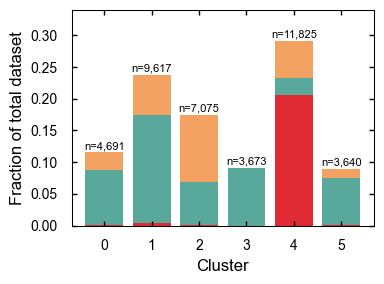

In [68]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, labels_ESM2)
n_total = cm.sum()
n_clusters = cm.shape[1]
cluster_sizes = cm.sum(axis=0)
cluster_labels = [str(i) for i in range(n_clusters)]
true_names = ['Bio', 'Dimer', 'FINCHES']
colors = ['#e02b35', '#59a89c', '#f4a261']
cm_frac = cm.astype(float) / n_total

fig, ax = plt.subplots(figsize=(4,3))

make_nice_axis(ax)

bottom = np.zeros(n_clusters)
for i, (name, color) in enumerate(zip(true_names, colors)):
    ax.bar(cluster_labels, cm_frac[i], bottom=bottom, label=name, color=color)
    bottom += cm_frac[i]

for j in range(n_clusters):
    ax.text(
        j, bottom[j] + 0.002,
        f'n={cluster_sizes[j]:,}',
        ha='center', va='bottom',
        fontsize=8,
    )
ax.set_ylabel('Fraction of total dataset')
ax.set_xlabel('Cluster')
ax.set_ylim(0, 0.34)

plt.tight_layout()
fig_save = True
fig_name = 'figSI6/cluster_composition_esm2'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

Output/figSI6/cluster_composition_dimer


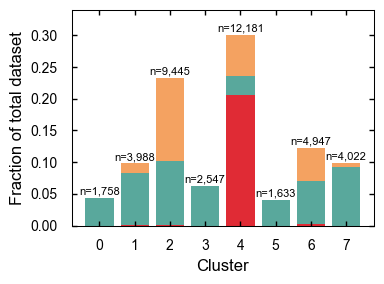

In [69]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, labels_dimer)
n_total = cm.sum()
n_clusters = cm.shape[1]
cluster_sizes = cm.sum(axis=0)
cluster_labels = [str(i) for i in range(n_clusters)]
true_names = ['Bio', 'Dimer', 'FINCHES']
colors = ['#e02b35', '#59a89c', '#f4a261']
cm_frac = cm.astype(float) / n_total

fig, ax = plt.subplots(figsize=(4,3))

make_nice_axis(ax)

bottom = np.zeros(n_clusters)
for i, (name, color) in enumerate(zip(true_names, colors)):
    ax.bar(cluster_labels, cm_frac[i], bottom=bottom, label=name, color=color)
    bottom += cm_frac[i]

for j in range(n_clusters):
    ax.text(
        j, bottom[j] + 0.002,
        f'n={cluster_sizes[j]:,}',
        ha='center', va='bottom',
        fontsize=8,
    )
ax.set_ylabel('Fraction of total dataset')
ax.set_xlabel('Cluster')
ax.set_ylim(0, 0.34)

plt.tight_layout()
fig_save = True
fig_name = 'figSI6/cluster_composition_dimer'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

### SI 7 ###

In [70]:
path_to_7_data = figures_data_dir + '/SI7/data'
df = pd.read_csv(path_to_7_data + '/si_7_data.csv')

fig_save = True

Output/figSI7/salt_methyl_10


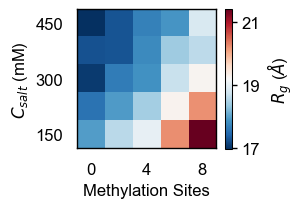

Output/figSI7/salt_methyl_1010


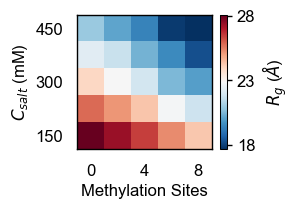

Output/figSI7/methyl_phos_1


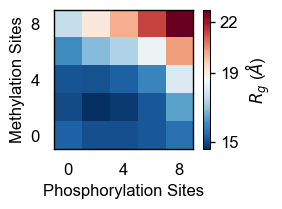

Output/figSI7/methyl_phos_1000


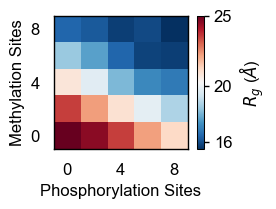

Output/figSI7/salt_phos_1100


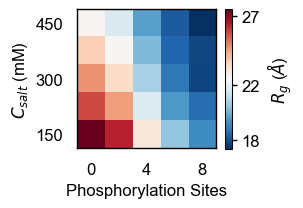

Output/figSI7/salt_phos_10


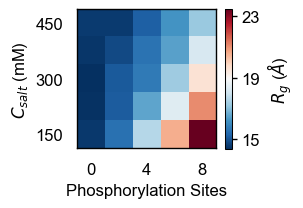

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def parse_rgs(txt: str) -> np.ndarray:
    rows = []
    for line in txt.strip().splitlines():
        line = line.strip().strip("[]")
        if line:
            rows.append([float(x) for x in line.split()])

    return np.array(rows)


methyl_levels = ['0', '2', '4', '6', '8']
phosp_labels = ['0', '2', '4', '6', '8']



possible_targets = df['targets'].unique()

for i, row in df.iterrows():

    data = parse_rgs(row['rgs'])

    conditions = row['conditions']
    targets = row['targets']

    label = f"{conditions}_{targets}"


    plt.rcParams["font.family"] = "Arial"

    fig, ax = plt.subplots(figsize=(3, 2.25))
    make_nice_axis(ax)
    data_transposed = data

    h, w = data_transposed.shape

    im = ax.imshow(
        data_transposed,
        cmap="RdBu_r",
        # vmin=17, vmax=22,
        interpolation="none",
        resample=False,
        origin="lower",                     # bottom-left origin
        extent=(-0.5, w - 0.5, -0.5, h - 0.5),  # pixel-aligned edges
    )
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)
    ax.set_aspect("equal")
    ax.grid(False)

    if row['conditions'] == 'methyl_phos':
        ytick_labels = ["0", "", "4", "", "8"]
        xtick_labels = ["0", "", "4", "", "8"]

        ylabel = 'Methylation Sites'
        xlabel = 'Phosphorylation Sites'
    elif row['conditions'] == 'salt_methyl':
        ytick_labels = ['150', '', '300', '', '450']
        xtick_labels = ["0", "", "4", "", "8"]

        ylabel = '$C_{salt}$ (mM)'
        xlabel = 'Methylation Sites'
    elif row['conditions'] == 'salt_phos':
        ytick_labels = ['150', '', '300', '', '450']
        xtick_labels = ["0", "", "4", "", "8"]

        ylabel = '$C_{salt}$ (mM)'
        xlabel = 'Phosphorylation Sites'


    ax.set_xticks(range(w))
    ax.set_yticks(range(h))
    ax.set_yticklabels(ytick_labels, fontsize=12)
    ax.set_xticklabels(xtick_labels, fontsize=12)
    ax.tick_params(axis="both", which="both", length=0)

    ax.spines['right'].set_linewidth(1)
    ax.spines['top'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=12)

    cbar = plt.colorbar(im, ax=ax, shrink=1.0)
    cbar.set_label(r"$R_g$ ($\AA$)", fontsize=12)


    max_vertical = data_transposed.max()
    min_vertical = data_transposed.min()

    import math
    
    cbar.set_ticks([math.ceil(min_vertical), round((min_vertical + max_vertical) / 2), math.floor(max_vertical)])
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout()
    fig_name = f"figSI7/{label}"
    if fig_save:
        print(save_dir + "/" + fig_name)
        save_figure(fig, fig_file=save_dir + "/" + fig_name)
    plt.show()

### SI 8 ###

In [72]:
path_to_8_data = figures_data_dir + '/SI8/data/'
fig8a_data = pd.read_csv(path_to_8_data + 'twoseq_density_data.csv')
fig8c_data = pd.read_csv(path_to_8_data + '2droplet_5seq.csv')

Output/figSI8/fig8a_mixed


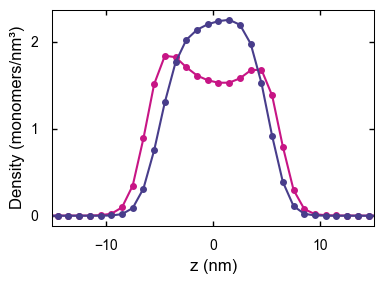

In [73]:
idp1 = fig8a_data["mixed_idp1_intensity"].values
idp2 = fig8a_data["mixed_idp2_intensity"].values
z = fig8a_data["z"].values

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color="#C71585", linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color="#483D8B", linewidth=1.5, markersize=4, label="IDP2")
ax.set_yticks([0, 1.0, 2.0])
ax.set_xticks([-10, 0, 10])
ax.set_xlim(-15, 15)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")

plt.tight_layout()
fig_save = True
fig_name = "figSI8/fig8a_mixed"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

Output/figSI8/fig8b_unmixed


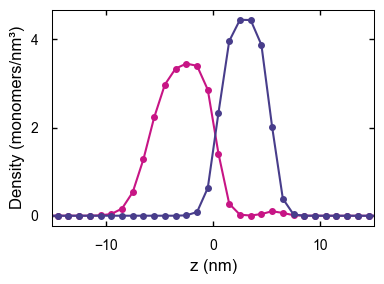

In [74]:
idp1 = fig8a_data["unmixed_idp1_intensity"].values
idp2 = fig8a_data["unmixed_idp2_intensity"].values
z = fig8a_data["z"].values

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color="#C71585", linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color="#483D8B", linewidth=1.5, markersize=4, label="IDP2")
ax.set_yticks([0, 2.0, 4.0])
ax.set_xticks([-10, 0, 10])
ax.set_xlim(-15, 15)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")

plt.tight_layout()
fig_save = True
fig_name = "figSI8/fig8b_unmixed"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

Output/figSI8/fig8c_2droplet_5seq


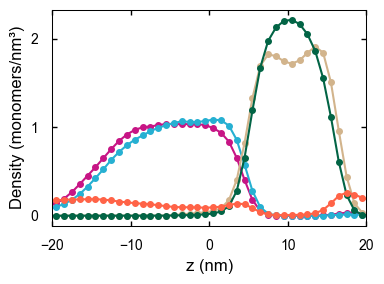

In [75]:
idp1 = fig8c_data["idp1_intensity"].values
idp2 = fig8c_data["idp2_intensity"].values
idp3 = fig8c_data["idp3_intensity"].values
idp4 = fig8c_data["idp4_intensity"].values
idp5 = fig8c_data["idp5_intensity"].values
z = fig8c_data["z"].values

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color='#C71585', linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color='#26B0D2', linewidth=1.5, markersize=4, label="IDP2")
ax.plot(z, idp3, "o-", color='#D2B48C', linewidth=1.5, markersize=4, label="IDP3")
ax.plot(z, idp4, "o-", color='#026445', linewidth=1.5, markersize=4, label="IDP4")
ax.plot(z, idp5, "o-", color='#FF6347', linewidth=1.5, markersize=4, label="IDP5")
ax.set_yticks([0, 1.0, 2.0])
ax.set_xticks([-20, -10, 0, 10, 20])
ax.set_xlim(-20, 20)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")

plt.tight_layout()
fig_save = True
fig_name = "figSI8/fig8c_2droplet_5seq"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

### SI 9 ###

In [76]:
path_to_si9_data = figures_data_dir + '/SI9/data/'
df = pd.read_csv(path_to_si9_data + 'nuclear_seqs_chi.csv')

Output/figSI9/figSI9_nuclear_chis


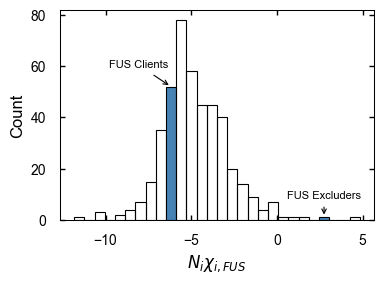

In [77]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

nuclear_chis = df['n_chi'].values

# Compute bin edges automatically
counts, bin_edges = np.histogram(nuclear_chis, bins='auto')

highlight_values = [-6.0, 3.0]

# ── Edit these to change annotation text ──────────────────────────────────────
annotation_labels = {
    -6.0: "FUS Clients",
    3.0:  "FUS Excluders",
}
# ──────────────────────────────────────────────────────────────────────────────

counts, bin_edges = np.histogram(nuclear_chis, bins='auto')
fig, ax = plt.subplots(figsize=(4, 3))
make_nice_axis(ax)

highlighted_bars = {}  # store (x_center, height) for annotated bins

for i, (left, right, count) in enumerate(zip(bin_edges[:-1], bin_edges[1:], counts)):
    filled = any(left <= v < right for v in highlight_values)
    ax.bar(left, count, width=right - left, align='edge',
           facecolor='steelblue' if filled else 'none',
           edgecolor='black', linewidth=0.8)
    if filled:
        matched = [v for v in highlight_values if left <= v < right]
        for v in matched:
            highlighted_bars[v] = (left + (right - left) / 2, count)

for v, (x_center, bar_height) in highlighted_bars.items():
    label = annotation_labels.get(v, str(v))
    if label == 'FUS Excluders':
        ax.annotate(
            label,
            xy=(x_center, bar_height),
            xytext=(x_center, bar_height + ax.get_ylim()[1] * 0.08),
            ha='center', va='bottom', fontsize=8,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                    edgecolor='white', linewidth=0.8),
        )
    else:
        ax.annotate(
            label,
            xy=(x_center, bar_height),
            xytext=(x_center - 1.9, bar_height + ax.get_ylim()[1] * 0.08),
            ha='center', va='bottom', fontsize=8,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                    edgecolor='white', linewidth=0.8),
        )

ax.set_xlabel('$N_i \chi_{i,FUS}$')
ax.set_ylabel('Count')
plt.tight_layout()
fig_save = True
fig_name = "figSI9/figSI9_nuclear_chis"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)

plt.show()

Output/figSI9/figSI9_partition_ratios


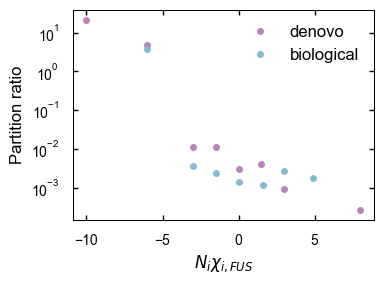

In [78]:
N_i_chi = np.array([-10, -6, -3, -1.5, 0, 1.5, 3, 8])
c_dense_101 = np.array([0.2078169297795550, 0.1330838764043570, 0.0006694872639536820, 0.0007017023116504910, 
                        0.00018860446106131700, 0.0002524488283149930, 5.6815629574372E-05, 1.58146597784335E-05])
c_dilute_101 = np.array([0.009547222249019290, 0.028230485592818600, 0.061334082877919500, 0.061326029115995300, 
                         0.06145430357864260, 0.06143834248682920, 0.06148725078651430, 0.061497501028963400])
PC_syn = c_dense_101/c_dilute_101

N_i_chi_bio = np.array([-6, -3, -1.5, 0, 1.6, 3, 4.9])
c_dense_101bio = np.array([0.11788818277538500, 0.0002219519164953480, 0.00014494709040536000, 8.60160205509201E-05, 
                           7.35605634574192E-05, 0.0001612521362444300, 0.00010913927211868500])
c_dilute_101bio = np.array([0.03202940900006190, 0.06144596671478410, 0.061465217921306700, 0.06147995068877020, 
                            0.06148306455304360, 0.06146114165984680, 0.061474169875878000])
PC_bio = c_dense_101bio/c_dilute_101bio

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 
denovo_color = '#B883BA'
biological_color = '#84BBD2'

ax.plot(N_i_chi, PC_syn, marker='o', color=denovo_color, markersize=4, label='denovo',linewidth=0)
ax.plot(N_i_chi_bio, PC_bio, marker='o', color=biological_color, markersize=4, label='biological',linewidth=0)
ax.set_yscale('log')
ax.set_xlabel(r'$N_i\chi_{i,FUS}$')
ax.set_ylabel('Partition ratio')
ax.legend(frameon=False)
plt.tight_layout()
fig_save = True
fig_name = "figSI9/figSI9_partition_ratios"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

### SI 10 ###

In [79]:
path_to_10_data = figures_data_dir + '/SI10/data/'
df = pd.read_csv(path_to_10_data + 'Fig10_normalized.csv')

Output/figSI10/fig10a


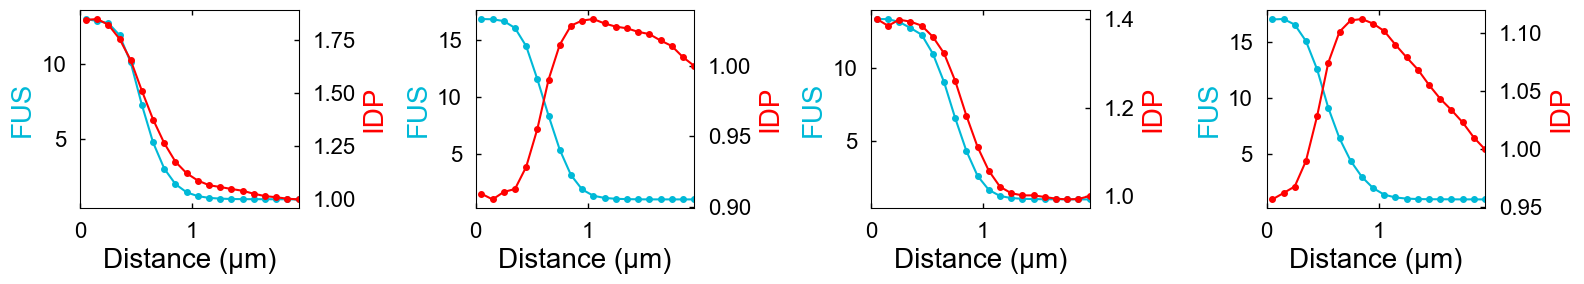

In [80]:

categories_order = ['client_bio', 'excluder_bio', 'client_denovo', 'excluder_denovo']

fus_color = '#00b9d7'
protein_color = 'red'


fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharex=True)  
for idx, category in enumerate(categories_order):
    if idx < len(axes):
        ax1 = axes[idx]
        
       
        cat_data = df[df['category'] == category].sort_values('distance_um')
        
        if len(cat_data) == 0:
            ax1.axis('off')
            continue
        
        protein_vals = cat_data['protein_intensity_normalized'].values
        fus_vals = cat_data['fus_intensity_normalized'].values
        dist_vals = cat_data['distance_um'].values
        
        n_profiles = cat_data['n_profiles'].iloc[0] if 'n_profiles' in cat_data.columns else len(cat_data)
        
        valid_fus = ~pd.isna(fus_vals)
        ax1.plot(
            dist_vals[valid_fus],
            fus_vals[valid_fus],
            'o-', lw=1.5, color=fus_color,
            label='FUS intensity', markersize=4
        )
        make_nice_axis(ax1) 
        ax1.tick_params(axis='both', labelsize=16)
        ax1.set_xlabel("Distance (µm)",fontsize=20)
        ax1.set_ylabel("FUS", color=fus_color,fontsize=20)
        
        ax2 = ax1.twinx()
        valid_protein = ~pd.isna(protein_vals)
        ax2.plot(
            dist_vals[valid_protein],
            protein_vals[valid_protein],
            'o-', lw=1.5, color=protein_color,
            label='Protein intensity', markersize=4
        )
        make_nice_axis(ax2) 
        ax2.tick_params(axis='both', labelsize=16)
        ax2.set_ylabel("IDP", color=protein_color,fontsize=20)
        ax1.set_xlim(0, dist_vals.max())
plt.tight_layout()
fig_save = True
fig_name = "figSI10/fig10a"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()
